# Activity Cliff-aware ΔpKi 예측 파이프라인

한 곳만 다른 분자쌍 (A, B)를 입력받아 **Δ = pKi(B) − pKi(A)** 를 직접 예측한다.
3D CNN 인코더는 별도로 개발하고, 이 노트북에서는 그 앞뒤(입력 · 손실 · 평가 · 설명)를 만든다.

| AC-aware 아이디어 | 이 노트북에서의 구현 |
|---|---|
| ① 표현 | A, B + **바뀐 조각**(MCS 밖 원자) + 편집 종류(replace/insert/delete) + 타깃 one-hot |
| ② 손실 | `w = 1 + α·|Δ_true|`, 배치별 `Σw` 정규화, α는 validation cliff RMSE로 탐색 |
| ③ 설명 | 원자별 기여도 → 편집 부위에 몰린 비율 기록 |
| ④ 평가 | {train, easy, hard} × {cliff, non-cliff} RMSE, baseline(ECFP+SVR 개별 예측 후 차이)과 비교 |

진행 순서: **1. 데이터 → 2. 분자 split → 3. 쌍 정의 → 4. 쌍 생성** → (다음) 인코더 · 손실 · 평가 · 설명

In [1]:
import os, urllib.request
from multiprocessing import Pool
import numpy as np, pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFMCS, rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')

DATA, PAIRS = 'data/moleculeace', 'data/pairs'
# 개발용: 작고 cliff 비율 높은 타깃 4개 (Ki 2 + EC50 2). 괜찮으면 30개로 늘린다
# CHEMBL2835_Ki는 쌍은 많지만 cliff 2%라 제외
DEV_TARGETS = ['CHEMBL1862_Ki', 'CHEMBL237_EC50', 'CHEMBL4616_EC50', 'CHEMBL2034_Ki']
SEED = 0
CLIFF = 1.0         # |Δ| >= 1 → cliff (MoleculeACE 기준, 10배)
VAL_FRAC = 0.2      # train 분자 중 validation 비율
SIM_MIN = 0.5       # ECFP4 Tanimoto 사전 필터 (MCS 통과 쌍의 99.5% 유지)
MAX_CHANGED = 10    # 한쪽에서 바뀐 원자 수 상한 (MMP 관례)
MCS_TIMEOUT = 1     # 초. 2초로 늘려도 통과 쌍 거의 같음
N_JOBS = 32
os.makedirs(DATA, exist_ok=True); os.makedirs(PAIRS, exist_ok=True)

## 1. 데이터: MoleculeACE

30개 ChEMBL 타깃(Ki 21개 + EC50 9개)을 모두 사용한다. 쓰는 열은 다음과 같다.
- `smiles`
- `y [pEC50/pKi]` → `p`로 이름 변경. 단위가 −log10(M)라서 Δ는 로그 단위 차이
- `split`: MoleculeACE가 정해둔 분자 단위 train/test

In [2]:
URL = 'https://raw.githubusercontent.com/molML/MoleculeACE/main/MoleculeACE/Data/benchmark_data/'
TARGETS = ['CHEMBL1862_Ki', 'CHEMBL1871_Ki', 'CHEMBL2034_Ki', 'CHEMBL2047_EC50', 'CHEMBL204_Ki', 'CHEMBL2147_Ki',
           'CHEMBL214_Ki', 'CHEMBL218_EC50', 'CHEMBL219_Ki', 'CHEMBL228_Ki', 'CHEMBL231_Ki', 'CHEMBL233_Ki',
           'CHEMBL234_Ki', 'CHEMBL235_EC50', 'CHEMBL236_Ki', 'CHEMBL237_EC50', 'CHEMBL237_Ki', 'CHEMBL238_Ki',
           'CHEMBL239_EC50', 'CHEMBL244_Ki', 'CHEMBL262_Ki', 'CHEMBL264_Ki', 'CHEMBL2835_Ki', 'CHEMBL287_Ki',
           'CHEMBL2971_Ki', 'CHEMBL3979_EC50', 'CHEMBL4005_Ki', 'CHEMBL4203_Ki', 'CHEMBL4616_EC50', 'CHEMBL4792_Ki']
for t in TARGETS:
    if not os.path.exists(f'{DATA}/{t}.csv'):
        urllib.request.urlretrieve(f'{URL}{t}.csv', f'{DATA}/{t}.csv')
pd.Series({t: len(pd.read_csv(f'{DATA}/{t}.csv')) for t in TARGETS}, name='n_mols').sort_values().to_frame().T

,CHEMBL2835_Ki,CHEMBL2047_EC50,CHEMBL1871_Ki,CHEMBL4616_EC50,CHEMBL4203_Ki,CHEMBL2034_Ki,CHEMBL1862_Ki,CHEMBL262_Ki,CHEMBL237_EC50,CHEMBL4005_Ki,...,CHEMBL219_Ki,CHEMBL235_EC50,CHEMBL236_Ki,CHEMBL237_Ki,CHEMBL204_Ki,CHEMBL264_Ki,CHEMBL244_Ki,CHEMBL233_Ki,CHEMBL214_Ki,CHEMBL234_Ki
n_mols,615,631,659,682,731,750,794,856,955,960,...,1865,2349,2598,2603,2754,2862,3097,3142,3317,3657


## 2. 분자 split: train / val / test

α 탐색을 test로 하면 성능이 부풀려지므로, MoleculeACE **train 분자의 20%를 val 분자**로 떼어낸다.
분자 단위로 나누기 때문에 쌍의 난이도는 두 분자가 어디에 속하는지로 정해진다.

| 쌍 split | A, B 분자 | 의미 |
|---|---|---|
| `train` | train, train | 학습 |
| `val_easy` / `test_easy` | train, val/test | 한 분자는 학습 때 봄 |
| `val_hard` / `test_hard` | val/test, val/test | 두 분자 모두 처음 |

val–test 섞인 쌍은 어느 쪽에도 속하지 않아 버린다.

In [3]:
def load(target):
    df = pd.read_csv(f'{DATA}/{target}.csv').rename(columns={'y [pEC50/pKi]': 'p'})[['smiles', 'p', 'cliff_mol', 'split']]
    train = df.index[df.split == 'train']
    rng = np.random.default_rng(SEED)
    # ponytail: 단순 무작위 추출. val 결과가 흔들리면 cliff_mol 기준 층화 추출로 바꾼다
    df.loc[rng.choice(train, int(len(train) * VAL_FRAC), replace=False), 'split'] = 'val'
    return df

pd.DataFrame({t: load(t).split.value_counts() for t in DEV_TARGETS}).T

split,train,test,val
CHEMBL1862_Ki,507,161,126
CHEMBL237_EC50,610,193,152
CHEMBL4616_EC50,435,139,108
CHEMBL2034_Ki,479,152,119


## 3. "한 곳만 다른 쌍" 정의

A와 B의 MCS(최대 공통 부분구조)를 구한 뒤, MCS에 들지 않은 원자를 **바뀐 원자**로 본다.
아래 조건을 모두 만족하면 한 곳만 다른 쌍으로 인정한다.

1. 바뀐 원자가 A, B 각각에서 **연결된 한 덩어리** 이하일 것
2. 양쪽 모두 바뀌었으면(replace) 두 덩어리가 **같은 MCS 원자에 붙어 있을 것**. 즉 같은 자리에서 바뀐 것
3. 한쪽 바뀐 원자 수 ≤ `MAX_CHANGED`

편집 종류는 A → B 기준으로 정한다.
- **replace**: 양쪽 모두 바뀜. 예) F → OCH3, 고리 원자 C → N
- **insert**: A에는 바뀐 원자가 없음. 예) H → F
- **delete**: B에는 바뀐 원자가 없음

MCS 설정은 원소 · 결합차수 일치, 고리 결합은 고리 결합끼리만 매칭하는 것이다.
고리 전체 일치(`completeRingsOnly`)는 쓰지 않는다. 쓰면 고리 원자 하나 치환(C → N)이 고리 통째 교체로 잡히고, 속도도 2배 느리다.
입체이성질체끼리만 다른 쌍은 2D에서 차이가 없으므로 제외한다(`identical_2d`).

In [4]:
def n_components(mol, atoms):
    left, n = set(atoms), 0
    while left:
        n += 1
        stack = [left.pop()]
        while stack:
            for nb in mol.GetAtomWithIdx(stack.pop()).GetNeighbors():
                if nb.GetIdx() in left:
                    left.remove(nb.GetIdx()); stack.append(nb.GetIdx())
    return n

def anchors(mol, changed, match):
    """바뀐 원자에 붙은 MCS 원자를 MCS 쿼리 내 순번으로 반환"""
    pos = {x: k for k, x in enumerate(match)}
    return {pos[nb.GetIdx()] for a in changed for nb in mol.GetAtomWithIdx(a).GetNeighbors() if nb.GetIdx() in pos}

def single_site(sa, sb):
    """한 곳만 다르면 (edit, atoms_a, atoms_b), 아니면 탈락 사유 문자열"""
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    if r.canceled:
        return 'timeout'
    q = Chem.MolFromSmarts(r.smartsString)
    ma = a.GetSubstructMatch(q)
    ca = [i for i in range(a.GetNumAtoms()) if i not in ma]
    # 대칭 분자는 매칭이 여러 개라 anchor 순번이 달라질 수 있어 B의 매칭을 모두 확인
    for mb in b.GetSubstructMatches(q, uniquify=False, maxMatches=1000):
        cb = [i for i in range(b.GetNumAtoms()) if i not in mb]
        if not ca and not cb:
            return 'identical_2d'
        if max(len(ca), len(cb)) > MAX_CHANGED:
            return 'too_big'
        if n_components(a, ca) > 1 or n_components(b, cb) > 1:
            continue
        if not ca or not cb or anchors(a, ca, ma) == anchors(b, cb, mb):
            return ('insert' if not ca else 'delete' if not cb else 'replace'), ca, cb
    return 'multi_site'

In [5]:
# 판정 규칙 확인
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1')[0] == 'replace'  # 치환기 교체
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(F)cc1')[0] == 'insert'      # H → F
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1')[0] == 'delete'      # F → H
assert single_site('Cc1ccccc1', 'Cc1ccncc1')[0] == 'replace'                     # 고리 원자 C → N
assert single_site('Fc1ccc(Cl)cc1', 'Nc1ccc(Br)cc1') == 'multi_site'             # 두 곳 변경
assert single_site('C[C@H](N)O', 'C[C@@H](N)O') == 'identical_2d'                # 입체만 다름
single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(OC)cc1')

('replace', [8], [8, 9])

## 4. 쌍 생성

1. ECFP4 Tanimoto ≥ `SIM_MIN`인 후보만 남긴다. MCS는 비싸기 때문
2. val–test 후보는 MCS 전에 버린다
3. 병렬로 `single_site` 판정
4. `data/pairs/{target}.pkl`에 캐시한다. 판정 기준을 바꾸면 파일을 지우고 다시 돌린다

쌍은 한 방향 (i < j)으로만 저장한다. 역방향 `(B, A, −Δ)`은 학습 시점에 추가한다.

In [6]:
FPGEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
PAIR_SPLIT = {('train', 'train'): 'train', ('train', 'val'): 'val_easy', ('val', 'val'): 'val_hard',
              ('test', 'train'): 'test_easy', ('test', 'test'): 'test_hard'}

def _job(args):
    i, j, sa, sb = args
    try:
        return i, j, single_site(sa, sb)
    except Exception:
        return i, j, 'error'

def make_pairs(target):
    path = f'{PAIRS}/{target}.pkl'
    if os.path.exists(path):
        cached = pd.read_pickle(path)
        print(f'{target}: 캐시 {len(cached)}쌍 (cliff {cached.is_cliff.sum()})')
        return cached
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    cand = [(i, j) for i in range(len(df))
            for j, s in enumerate(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]), i + 1) if s >= SIM_MIN]
    cand = [(i, j) for i, j in cand if tuple(sorted((df.split[i], df.split[j]))) in PAIR_SPLIT]
    with Pool(N_JOBS) as pool:
        res = pool.map(_job, [(i, j, df.smiles[i], df.smiles[j]) for i, j in cand], chunksize=20)

    rows = []
    for i, j, r in res:
        if isinstance(r, str):
            continue
        edit, ca, cb = r
        a, b = Chem.MolFromSmiles(df.smiles[i]), Chem.MolFromSmiles(df.smiles[j])
        rows.append(dict(i=i, j=j, smiles_a=df.smiles[i], smiles_b=df.smiles[j], p_a=df.p[i], p_b=df.p[j],
                         delta=df.p[j] - df.p[i], edit=edit, atoms_a=ca, atoms_b=cb,
                         frag_a=Chem.MolFragmentToSmiles(a, ca) if ca else '',
                         frag_b=Chem.MolFragmentToSmiles(b, cb) if cb else '',
                         split=PAIR_SPLIT[tuple(sorted((df.split[i], df.split[j])))]))
    pairs = pd.DataFrame(rows)
    pairs['is_cliff'] = pairs.delta.abs() >= CLIFF
    pairs.to_pickle(path)
    print(f'{target}: 후보 {len(cand)} → {len(pairs)}쌍 (cliff {pairs.is_cliff.sum()})',
          pd.Series([r for _, _, r in res if isinstance(r, str)]).value_counts().to_dict())
    return pairs

pairs = pd.concat([make_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True)
# 각 분자가 속한 split (쌍 split의 근거)
mol_split = {t: load(t).split for t in DEV_TARGETS}
pairs['split_a'] = [mol_split[t][i] for t, i in zip(pairs.target, pairs.i)]
pairs['split_b'] = [mol_split[t][j] for t, j in zip(pairs.target, pairs.j)]

CHEMBL1862_Ki: 캐시 6892쌍 (cliff 2909)
CHEMBL237_EC50: 캐시 3283쌍 (cliff 1422)
CHEMBL4616_EC50: 캐시 2092쌍 (cliff 594)
CHEMBL2034_Ki: 캐시 2009쌍 (cliff 385)


## 5. 쌍 확인

**4개 타깃의 쌍을 합쳐서 쌍 모델 하나를 학습·평가한다.** 타깃별 모델보다 cliff 수가 많아 α 탐색과 평가가 안정적이다.
- 쌍은 같은 타깃 안에서만 만든다(4번). 다른 타깃 분자끼리의 Δ는 의미가 없다
- split은 쌍을 섞어 나누지 않는다. 타깃마다 분자 단위로 나눈 split(2번)을 쌍이 물려받는다
- 같은 구조 변화도 타깃마다 효과가 다르므로 **타깃 one-hot을 입력에 추가**한다
- 평가는 전체 합계 표와 타깃별 표를 함께 본다
- baseline(ECFP+SVR)은 MoleculeACE 방식대로 타깃별로 학습한다

다음 네 가지를 본다.
- 타깃별 · 전체 split × cliff 분포: 쉬운/어려운 task마다 cliff 쌍이 충분한지
- 편집 종류 분포
- 바뀐 원자 수 분포: `MAX_CHANGED`가 적절한지
- cliff 예시

In [7]:
display(pd.crosstab(pairs.target, [pairs.split, pairs.is_cliff]))
pd.crosstab(pairs.split, pairs.is_cliff, margins=True)

split           test_easy       test_hard       train       val_easy        \
is_cliff            False True      False True  False True     False True    
target                                                                       
CHEMBL1862_Ki        1090   813       173   122  1710  1193      896   677   
CHEMBL2034_Ki         440   123        59    16   733   166      354    67   
CHEMBL237_EC50        586   419        97    36   779   680      364   259   
CHEMBL4616_EC50       441   176        71    27   670   244      284   135   

split           val_hard        
is_cliff           False True   
target                          
CHEMBL1862_Ki        114   104  
CHEMBL2034_Ki         38    13  
CHEMBL237_EC50        35    28  
CHEMBL4616_EC50       32    12

is_cliff,False,True,All
split,,,
test_easy,2557,1531,4088
test_hard,400,201,601
train,3892,2283,6175
val_easy,1898,1138,3036
val_hard,219,157,376
All,8966,5310,14276


In [8]:
n_changed = pairs[['atoms_a', 'atoms_b']].map(len).max(axis=1)
display(pairs.edit.value_counts().to_frame().T)
display(pd.crosstab(n_changed.rename('n_changed'), pairs.is_cliff).T)

edit,replace,insert,delete
count,11877,1478,921


n_changed,1,2,3,4,5,6,7,8,9,10
is_cliff,,,,,,,,,,
False,1203,678,574,706,631,1179,1220,1353,830,592
True,350,207,236,398,372,668,913,1164,640,362


In [9]:
pairs[pairs.is_cliff].sort_values('delta', key=abs, ascending=False) \
    [['target', 'frag_a', 'frag_b', 'edit', 'p_a', 'p_b', 'delta', 'split']].head(10)

,target,frag_a,frag_b,edit,p_a,p_b,delta,split
9252,CHEMBL237_EC50,CCC,,delete,5.033858,10.721246,5.687388,train
9245,CHEMBL237_EC50,COc1ccccc1,,delete,5.214670,10.721246,5.506576,val_easy
8878,CHEMBL237_EC50,CC1=CC(=O)C=CC1=O,C#Cc1ccco1,replace,5.602060,10.721246,5.119186,test_easy
8733,CHEMBL237_EC50,O=Cc1ccccc1,C#Cc1ccco1,replace,5.642065,10.721246,5.079181,train
8746,CHEMBL237_EC50,C=C\c1ccoc1,C#Cc1ccco1,replace,5.863279,10.721246,4.857967,test_easy
9020,CHEMBL237_EC50,FC(F)(F)c1ccccc1,C#C,replace,5.991400,10.721246,4.729847,train
9260,CHEMBL237_EC50,CCCO,,delete,6.050610,10.721246,4.670636,train
8067,CHEMBL237_EC50,,C#C,insert,6.124939,10.721246,4.596308,train
9270,CHEMBL237_EC50,C#C,Nc1ccccc1,replace,10.721246,6.200659,-4.520587,train
9271,CHEMBL237_EC50,C#C,Nc1ccccc1,replace,10.721246,6.207608,-4.513638,val_easy


## 6. 쌍 시각화

**cliff / non-cliff 쌍은 따로 뽑지 않는다.** 한 번에 만든 쌍에 나중에 라벨만 붙인다.

1. 같은 타깃 안의 모든 분자 조합 (i < j)
2. ECFP4 Tanimoto ≥ 0.5
3. MCS 기준으로 한 곳만 다름 (3번 규칙)
4. → 쌍 확정. 여기까지는 약효를 전혀 보지 않는다
5. 라벨 부여: `Δ = p(B) − p(A)`, `|Δ| ≥ 1`이면 cliff, 아니면 non-cliff

샘플링이나 cliff/non-cliff 비율 맞추기는 하지 않았다. 37%라는 cliff 비율은 데이터에서 자연스럽게 나온 값이다.

아래 그림은 {cliff, non-cliff} × {replace, insert, delete}마다 무작위로 1쌍씩 뽑은 것이다.

**그림 읽는 법**
- 한 줄이 한 쌍, 왼쪽이 A, 오른쪽이 B. B는 A의 공통 구조 배치에 맞춰 그렸으므로 **빨간 부분만 비교하면 된다**
- **빨간 원자** = MCS 밖에 있는 바뀐 원자. ① 표현에서 조각 인코더로 들어가는 부분
- 범례: `타깃  A [분자 split]  p` / `B [분자 split]  p  delta  cliff 여부 / 편집 종류 | 쌍 split`
- `delta`는 B − A이므로 양수면 B가 더 세다. `|delta| ≥ 1`이면 CLIFF
- replace는 양쪽 다, insert는 B만, delete는 A만 빨갛다

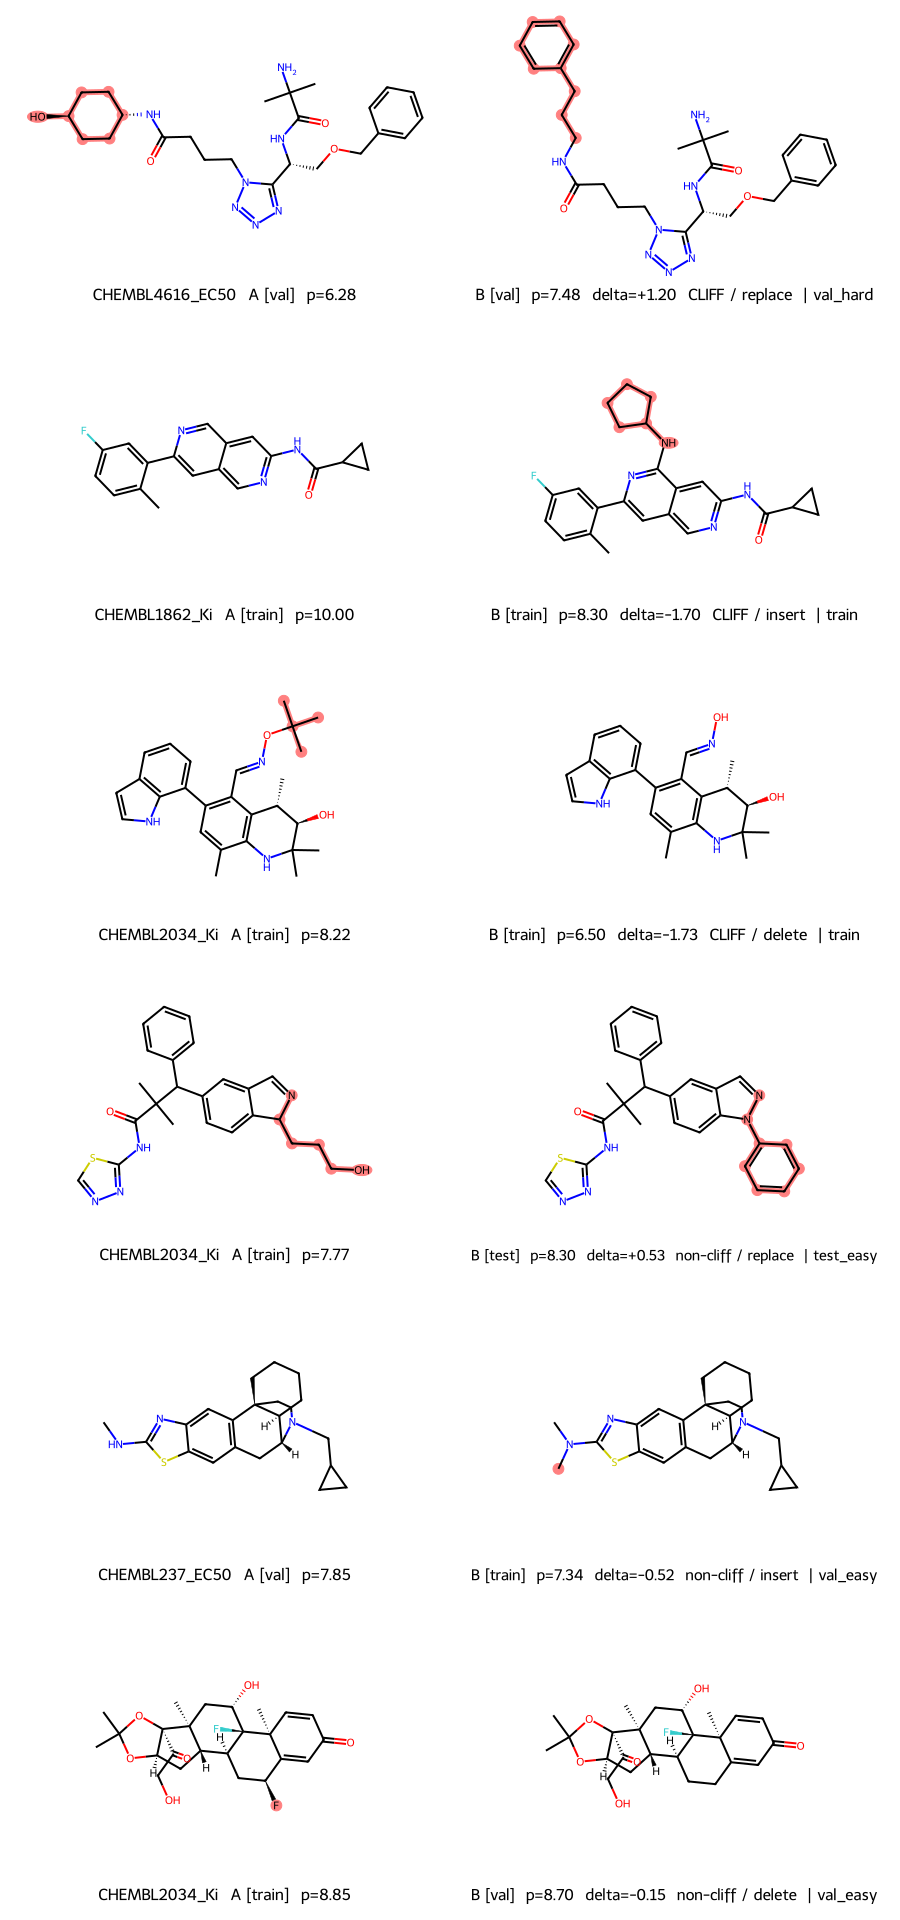

In [10]:
from rdkit.Chem import Draw, rdDepictor

def draw_pairs(rows):
    mols, highlights, legends = [], [], []
    for r in rows.itertuples():
        a, b = Chem.MolFromSmiles(r.smiles_a), Chem.MolFromSmiles(r.smiles_b)
        rdDepictor.Compute2DCoords(a)
        mcs = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                             bondCompare=rdFMCS.BondCompare.CompareOrder, ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
        rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=Chem.MolFromSmarts(mcs.smartsString), acceptFailure=True)
        mols += [a, b]
        highlights += [r.atoms_a, r.atoms_b]
        legends += [f'{r.target}  A [{r.split_a}]  p={r.p_a:.2f}',
                    f'B [{r.split_b}]  p={r.p_b:.2f}  delta={r.delta:+.2f}  {"CLIFF" if r.is_cliff else "non-cliff"} / {r.edit}  | {r.split}']
    return Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(450, 320), highlightAtomLists=highlights, legends=legends)

sample = pairs.groupby(['is_cliff', 'edit']).sample(1, random_state=SEED).sort_values(['is_cliff', 'edit'], ascending=False)
draw_pairs(sample)

## 7. easy / hard 기준 시각화

난이도는 **쌍을 이루는 두 분자가 학습 때 보인 분자인지**로 정한다. 분자 split(2번)을 쌍이 물려받는 것이다.
- **easy**: 한 분자는 train 분자. 모델이 그 분자가 들어간 다른 쌍을 학습에서 봤다
- **hard**: 두 분자 모두 val/test 분자. 둘 다 처음 보는 분자

쌍 자체는 split끼리 겹치지 않는다. 차이는 **분자를 본 적이 있느냐**다.

**그림 읽는 법**
- 두 줄 모두 오른쪽(B)이 **같은 test 분자 C**다. 왼쪽 짝만 다르다
- 1줄은 짝이 train 분자라 `test_easy`, 2줄은 짝도 test 분자라 `test_hard`
- 범례의 `[train]`/`[test]`가 각 분자의 split, 맨 끝이 그 쌍의 split
- 같은 분자라도 짝에 따라 난이도가 갈린다는 것이 요점이다

기준 분자 C = CHEMBL4616_EC50:635


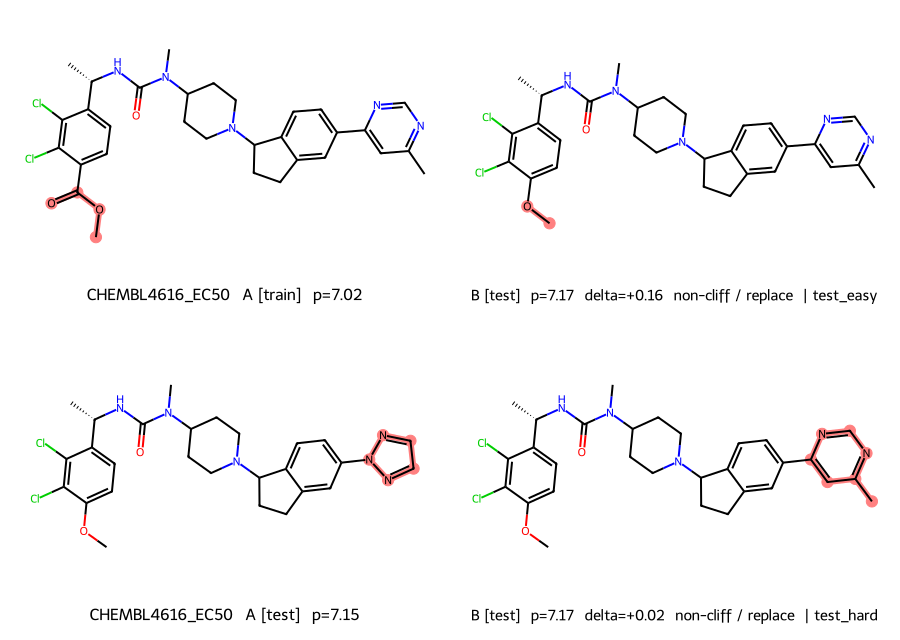

In [11]:
# 쌍마다 test 분자를 기준 분자(center)로 펼친 뒤, easy 쌍과 hard 쌍을 둘 다 가진 test 분자 하나 선택
long = pd.concat([pairs[pairs[s] == 'test'].assign(center=lambda x: x.target + ':' + x[m].astype(str))
                  for m, s in [('i', 'split_a'), ('j', 'split_b')]])
has_both = long.groupby('center').split.agg(lambda s: {'test_easy', 'test_hard'} <= set(s))
center = has_both[has_both].sample(1, random_state=SEED).index[0]
print('기준 분자 C =', center)
draw_pairs(long[long.center == center].groupby('split').sample(1, random_state=SEED).sort_values('split'))

In [12]:
# 분자 split 조합 → 쌍 split 대응 확인 (val–test 조합은 없어야 함)
pd.crosstab([pairs.split_a, pairs.split_b], pairs.split)

split            test_easy  test_hard  train  val_easy  val_hard
split_a split_b                                                 
test    test             0        601      0         0         0
        train         2066          0      0         0         0
train   test          2022          0      0         0         0
        train            0          0   6175         0         0
        val              0          0      0      1444         0
val     train            0          0      0      1592         0
        val              0          0      0         0       376

## 8. Baseline: ECFP + SVR (분자 단위 예측 → 차이)

기존 방식의 대표로, MoleculeACE에서 가장 성능이 좋았던 **ECFP + SVM** 조합을 쓴다.
1. 타깃마다 분자 하나씩 p를 예측하는 SVR을 학습한다. 커널은 Tanimoto(precomputed)
2. C는 **val 분자 RMSE**로 고른다. 쌍 모델의 α 탐색과 같은 규칙
3. 학습은 train 분자만 쓴다. 쌍 모델도 train 쌍만 쓰므로 조건이 같다
4. 쌍 예측은 `Δ̂ = ŷ(B) − ŷ(A)`

참고로 두 가지 기준선을 같이 둔다.
- **`zero`**: 항상 Δ̂ = 0, 즉 "구조를 바꿔도 약효는 그대로"라는 예측. RMSE의 눈금을 잡는 용도
- **분자 단위 RMSE**: MoleculeACE 논문 수치와 대략 비교하기 위한 test 분자 전체와 `cliff_mol=1` 분자 RMSE
  - train 분자의 20%를 val로 뗐기 때문에 논문보다 약간 나쁘게 나올 수 있다

In [13]:
from sklearn.svm import SVR

SVR_C = [1, 10, 100, 1000]

def ecfp(smiles):
    return np.array([FPGEN.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in smiles], dtype=np.float32)

def tanimoto(X, Y):
    inter = X @ Y.T
    return inter / (X.sum(1)[:, None] + Y.sum(1)[None, :] - inter)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def svr_predict(target):
    """train 분자로 학습, val로 C 선택 → 모든 분자의 예측값"""
    df = load(target)
    X = ecfp(df.smiles)
    tr, va = (df.split == 'train').values, (df.split == 'val').values
    K = tanimoto(X, X[tr])
    fit = lambda C: SVR(kernel='precomputed', C=C).fit(K[tr], df.p[tr])
    val_rmse = {C: rmse(fit(C).predict(K[va]), df.p[va]) for C in SVR_C}
    best = min(val_rmse, key=val_rmse.get)
    return df.assign(pred=fit(best).predict(K)), best

mol_pred, rows = {}, []
for t in DEV_TARGETS:
    d, C = svr_predict(t)
    mol_pred[t] = d.pred
    te = d[d.split == 'test']
    rows.append(dict(target=t, C=C, test_rmse=rmse(te.pred, te.p), test_rmse_cliff_mol=rmse(te.pred[te.cliff_mol == 1], te.p[te.cliff_mol == 1])))
pairs['pred_svr'] = [mol_pred[t][j] - mol_pred[t][i] for t, i, j in zip(pairs.target, pairs.i, pairs.j)]
pairs['pred_zero'] = 0.0
pd.DataFrame(rows).round(3)

,target,C,test_rmse,test_rmse_cliff_mol
0,CHEMBL1862_Ki,10,0.756,0.655
1,CHEMBL237_EC50,10,0.806,0.865
2,CHEMBL4616_EC50,1,0.707,0.760
3,CHEMBL2034_Ki,10,0.682,0.800


### 평가 표 (이후 모든 모델 공통)

쌍 split × {cliff, non-cliff} RMSE를 계산한다. 4개 타깃을 합친 표와 타깃별 test 표를 함께 본다.
- 모델 비교는 **test_easy / test_hard**로 한다
- val은 α · C 같은 하이퍼파라미터 선택용이다
- train 줄은 과적합 확인용이다. SVR은 train 분자를 외우므로 train 쌍 RMSE가 매우 낮게 나온다

In [14]:
SPLITS = ['train', 'val_easy', 'val_hard', 'test_easy', 'test_hard']

def rmse_table(df, col, index='split'):
    se = df.assign(se=(df[col] - df.delta) ** 2)
    t = se.pivot_table(index=index, columns='is_cliff', values='se', aggfunc='mean').rename(columns={False: 'non-cliff', True: 'cliff'})
    t['all'] = se.groupby(index).se.mean()
    return t[['cliff', 'non-cliff', 'all']] ** 0.5

pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff   cliff non-cliff    all  cliff non-cliff    all
split                                                    
train      1.806     0.515  1.172  0.483     0.194  0.332
val_easy   1.805     0.512  1.177  0.908     0.538  0.700
val_hard   1.842     0.500  1.250  1.284     0.640  0.963
test_easy  1.825     0.523  1.191  0.926     0.532  0.706
test_hard  1.856     0.540  1.160  1.269     0.620  0.891

In [15]:
# 타깃별 test (특정 타깃만 망가지는지 확인)
test = pairs[pairs.split.str.startswith('test')]
pd.concat({m: rmse_table(test, f'pred_{m}', ['target', 'split']) for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff                   cliff non-cliff    all  cliff non-cliff    all
target          split                                                    
CHEMBL1862_Ki   test_easy  1.805     0.535  1.247  0.800     0.529  0.659
                test_hard  1.864     0.574  1.277  1.168     0.659  0.905
CHEMBL2034_Ki   test_easy  1.670     0.483  0.890  1.086     0.442  0.640
                test_hard  1.735     0.491  0.912  1.390     0.570  0.817
CHEMBL237_EC50  test_easy  1.996     0.518  1.349  0.989     0.637  0.803
                test_hard  2.014     0.524  1.139  1.519     0.677  0.979
CHEMBL4616_EC50 test_easy  1.576     0.536  0.956  1.164     0.462  0.734
                test_hard  1.657     0.514  0.973  1.263     0.462  0.770

## 9. 그래프 입력

분자를 원자 = 노드, 결합 = 엣지 그래프로 바꾼다. 3D CNN이 준비되면 이 자리를 복셀 입력으로 바꾼다.
- **원자 특징**: 원소, 결합 수, 형식전하, 수소 수, 혼성, 방향족 여부, 고리 여부. 목록 밖 값은 "기타" 칸
- **결합 특징**: 결합 종류(단일/이중/삼중/방향족), 공액 여부
- **`mask`**: 쌍에서 바뀐 원자(3번의 `atoms_a` / `atoms_b`). 조각 인코더가 이 원자들만 모은다

쌍 샘플은 `(그래프 A, 그래프 B, 편집 종류, Δ)`이다.
- 학습 때만 역방향 `(B, A, 편집 반전, −Δ)`을 추가한다. insert ↔ delete, replace는 그대로
- 편집 종류는 구조만으로 계산하므로 val/test에도 입력으로 들어간다

In [16]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from rdkit.Chem.rdchem import HybridizationType as H, BondType as B

ELEMENTS = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'B', 'Si', 'Se']
HYBRID = [H.SP, H.SP2, H.SP3, H.SP3D, H.SP3D2]
BONDS = [B.SINGLE, B.DOUBLE, B.TRIPLE, B.AROMATIC]
EDITS = ['replace', 'insert', 'delete']
FLIP = {'replace': 'replace', 'insert': 'delete', 'delete': 'insert'}

def onehot(x, choices):
    return [float(x == c) for c in choices] + [float(x not in choices)]

def atom_features(a):
    return (onehot(a.GetSymbol(), ELEMENTS) + onehot(a.GetDegree(), [0, 1, 2, 3, 4, 5]) + onehot(a.GetFormalCharge(), [-1, 0, 1])
            + onehot(a.GetTotalNumHs(), [0, 1, 2, 3]) + onehot(a.GetHybridization(), HYBRID) + [float(a.GetIsAromatic()), float(a.IsInRing())])

def graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    src, dst, edge = [], [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        f = onehot(b.GetBondType(), BONDS) + [float(b.GetIsConjugated())]
        src += [i, j]; dst += [j, i]; edge += [f, f]
    return Data(x=torch.tensor([atom_features(a) for a in mol.GetAtoms()]),
                edge_index=torch.tensor([src, dst], dtype=torch.long).reshape(2, -1),
                edge_attr=torch.tensor(edge).reshape(-1, len(BONDS) + 2))

graphs = {(t, k): graph(s) for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
N_ATOM, N_BOND = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0))), len(BONDS) + 2

def with_mask(g, atoms):
    mask = torch.zeros(g.num_nodes, dtype=torch.bool)
    mask[torch.tensor(atoms, dtype=torch.long)] = True
    return Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, mask=mask)

def samples(df, both_directions=False):
    out = []
    for r in df.itertuples():
        ga, gb = with_mask(graphs[r.target, r.i], r.atoms_a), with_mask(graphs[r.target, r.j], r.atoms_b)
        out.append((ga, gb, EDITS.index(r.edit), r.delta))
        if both_directions:
            out.append((gb, ga, EDITS.index(FLIP[r.edit]), -r.delta))
    return out

def collate(batch):
    ga, gb, edit, y = zip(*batch)
    return Batch.from_data_list(ga), Batch.from_data_list(gb), torch.tensor(edit), torch.tensor(y, dtype=torch.float32)

ga, gb, edit, y = collate(samples(pairs.head(2)))
print('원자 특징', N_ATOM, '| 결합 특징', N_BOND, '| 배치 A 노드', ga.num_nodes, '| mask 원자', int(ga.mask.sum()), '| edit', edit.tolist())

/home/bising0922/micromamba/envs/aienv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


원자 특징 37 | 결합 특징 6 | 배치 A 노드 54 | mask 원자 12 | edit [0, 2]


## 10. GNN 쌍 모델 + 학습

| 부분 | 구현 | 구조도 |
|---|---|---|
| 분자 인코더 `mol` | GINE 3층(잔차 연결), A와 B 가중치 공유 → 원자 벡터 평균 = h | 3D CNN 인코더 |
| 조각 인코더 `frag` | 별도 가중치 GINE → **mask 원자 벡터만 평균** = f. 없으면 0 벡터 | ⑤ 바뀐 부분 인코더 |
| 헤드 | `[h(A), h(B), h(B)−h(A), f(A), f(B), 편집 one-hot]` → MLP → Δ̂ | 결합 벡터 → 예측 헤드 |

인코더는 원자별 벡터를 반환한다. ③ 설명(Grad-CAM)에서 원자 단위 기여도로 쓰기 위해서다.

**학습**
- 손실: `w = 1 + α·|Δ|`, `L = Σ w·(Δ̂−Δ)² / Σ w`
- Adam, lr 1e-3, 배치 256, 최대 200 epoch
- **조기 종료**: val cliff RMSE가 20 epoch 동안 개선이 없으면 멈추고, 최고 시점 가중치를 쓴다
- 학습한 가중치는 `runs/`에 저장한다. 파일이 있으면 다시 학습하지 않고 불러온다
- 진행 상황은 `runs/train.log`에 기록한다. 노트북 출력은 실행이 끝나야 저장되기 때문

In [17]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
HIDDEN, LAYERS, BATCH, LR, EPOCHS, PATIENCE = 128, 3, 256, 1e-3, 200, 20
ALPHAS = [0, 0.5, 1, 2, 4]
RUNS = 'runs'
os.makedirs(RUNS, exist_ok=True)

def log(*msg):
    print(*msg)
    with open(f'{RUNS}/train.log', 'a') as f:
        print(pd.Timestamp.now().strftime('%m-%d %H:%M:%S'), *msg, file=f)

class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Linear(N_ATOM, HIDDEN)
        self.convs = nn.ModuleList(GINEConv(nn.Sequential(nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, HIDDEN)), edge_dim=N_BOND)
                                   for _ in range(LAYERS))

    def forward(self, g):
        h = self.inp(g.x)
        for conv in self.convs:
            h = h + F.relu(conv(h, g.edge_index, g.edge_attr))
        return h  # 원자별 벡터

def masked_mean(h, g):
    m = g.mask.float().unsqueeze(1)
    return global_add_pool(h * m, g.batch, g.num_graphs) / global_add_pool(m, g.batch, g.num_graphs).clamp(min=1)

class PairModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mol, self.frag = GNN(), GNN()
        self.head = nn.Sequential(nn.Linear(5 * HIDDEN + len(EDITS), HIDDEN), nn.ReLU(), nn.Dropout(0.1), nn.Linear(HIDDEN, 1))

    def forward(self, ga, gb, edit):
        ha, hb = global_mean_pool(self.mol(ga), ga.batch), global_mean_pool(self.mol(gb), gb.batch)
        fa, fb = masked_mean(self.frag(ga), ga), masked_mean(self.frag(gb), gb)
        return self.head(torch.cat([ha, hb, hb - ha, fa, fb, F.one_hot(edit, len(EDITS)).float()], 1)).squeeze(1)

def predict(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE)).cpu() for ga, gb, e, _ in loader]).numpy()

train_loader = DataLoader(samples(pairs[pairs.split == 'train'], both_directions=True), BATCH, shuffle=True, collate_fn=collate)
val_cliff = pairs[pairs.split.str.startswith('val') & pairs.is_cliff]
val_cliff_loader = DataLoader(samples(val_cliff), 1024, collate_fn=collate)
all_loader = DataLoader(samples(pairs), 1024, collate_fn=collate)

def train(alpha, seed=SEED):
    path = f'{RUNS}/gnn_alpha{alpha}_seed{seed}.pt'
    torch.manual_seed(seed)
    model = PairModel().to(DEVICE)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path))
        log(f'alpha={alpha} 저장된 가중치 사용 | val_cliff_rmse={rmse(predict(model, val_cliff_loader), val_cliff.delta):.3f}')
        return model
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best, best_state, wait = float('inf'), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for ga, gb, e, y in train_loader:
            ga, gb, e, y = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), y.to(DEVICE)
            w = 1 + alpha * y.abs()
            loss = (w * (model(ga, gb, e) - y) ** 2).sum() / w.sum()
            opt.zero_grad(); loss.backward(); opt.step()
        score = rmse(predict(model, val_cliff_loader), val_cliff.delta)
        if score < best:
            best, wait = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 10 == 0 or wait >= PATIENCE:
            log(f'alpha={alpha} epoch={epoch} loss={loss.item():.3f} val_cliff_rmse={score:.3f} best={best:.3f}')
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    torch.save(best_state, path)  # 끝까지 학습한 경우에만 저장 → 중간에 끊겨도 캐시가 오염되지 않음
    return model

log(f'device={DEVICE} train_samples={len(train_loader.dataset)} val_cliff={len(val_cliff)}')
for a in ALPHAS:
    pairs[f'pred_gnn_a{a}'] = predict(train(a), all_loader)

device=cuda train_samples=12350 val_cliff=1295


alpha=0 저장된 가중치 사용 | val_cliff_rmse=0.992


alpha=0.5 저장된 가중치 사용 | val_cliff_rmse=0.983


alpha=1 저장된 가중치 사용 | val_cliff_rmse=0.969


alpha=2 저장된 가중치 사용 | val_cliff_rmse=1.039


alpha=4 저장된 가중치 사용 | val_cliff_rmse=0.939


In [18]:
# 학습 기록 (runs/train.log). 가중치가 캐시된 경우 이 셀이 실제 학습 과정을 보여준다
print(open(f'{RUNS}/train.log').read()[-3000:])

poch=90 loss=0.061 val_cliff_rmse=1.013 best=0.992
09-16 00:45:44 alpha=0 epoch=96 loss=0.029 val_cliff_rmse=1.018 best=0.992
09-16 00:45:49 alpha=0.5 epoch=0 loss=1.760 val_cliff_rmse=1.544 best=1.544
09-16 00:46:26 alpha=0.5 epoch=10 loss=0.459 val_cliff_rmse=1.124 best=1.124
09-16 00:47:02 alpha=0.5 epoch=20 loss=0.283 val_cliff_rmse=1.063 best=1.045
09-16 00:47:37 alpha=0.5 epoch=30 loss=0.306 val_cliff_rmse=1.047 best=1.013
09-16 00:48:12 alpha=0.5 epoch=40 loss=0.099 val_cliff_rmse=1.025 best=0.994
09-16 00:48:48 alpha=0.5 epoch=50 loss=0.115 val_cliff_rmse=1.002 best=0.983
09-16 00:49:23 alpha=0.5 epoch=60 loss=0.049 val_cliff_rmse=1.019 best=0.983
09-16 00:49:34 alpha=0.5 epoch=63 loss=0.081 val_cliff_rmse=1.022 best=0.983
09-16 00:49:39 alpha=1 epoch=0 loss=1.987 val_cliff_rmse=1.509 best=1.509
09-16 00:50:15 alpha=1 epoch=10 loss=0.539 val_cliff_rmse=1.086 best=1.086
09-16 00:50:50 alpha=1 epoch=20 loss=0.238 val_cliff_rmse=1.002 best=1.002
09-16 00:51:25 alpha=1 epoch=30 los

## 11. α 선택 + baseline 비교

1. **α 선택**: val cliff RMSE(val_easy + val_hard의 cliff 쌍)가 가장 낮은 α. non-cliff가 얼마나 손해 보는지 옆에 같이 본다
2. **최종 비교**는 test split에서 한다
   - `zero`
   - `svr`: baseline
   - `gnn_a0`: 쌍 모델, 가중치 없음
   - `gnn_best`: 쌍 모델, 선택된 α

In [19]:
val = pairs[pairs.split.str.startswith('val')]
# 열 이름과 맞추려고 문자열 키를 쓴다 (0과 0.5가 섞이면 pandas가 인덱스를 float으로 바꿔 'a4' → 'a4.0'이 됨)
alpha_table = pd.DataFrame({str(a): {'val cliff': rmse(val[val.is_cliff][f'pred_gnn_a{a}'], val[val.is_cliff].delta),
                                     'val non-cliff': rmse(val[~val.is_cliff][f'pred_gnn_a{a}'], val[~val.is_cliff].delta)}
                            for a in ALPHAS}).T.rename_axis('alpha')
BEST_ALPHA = alpha_table['val cliff'].idxmin()
pairs['pred_gnn_best'] = pairs[f'pred_gnn_a{BEST_ALPHA}']
log(f'best alpha = {BEST_ALPHA}')
alpha_table.round(3)

best alpha = 4


,val cliff,val non-cliff
alpha,,
0,0.992,0.781
0.5,0.983,0.779
1,0.969,0.743
2,1.039,0.776
4,0.939,0.766


In [20]:
MODELS = ['zero', 'svr', 'gnn_a0', 'gnn_best']
pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in MODELS}, axis=1).round(3)

zero                     svr                  gnn_a0            \
is_cliff   cliff non-cliff    all  cliff non-cliff    all  cliff non-cliff   
split                                                                        
train      1.806     0.515  1.172  0.483     0.194  0.332  0.187     0.183   
val_easy   1.805     0.512  1.177  0.908     0.538  0.700  0.944     0.754   
val_hard   1.842     0.500  1.250  1.284     0.640  0.963  1.290     0.984   
test_easy  1.825     0.523  1.191  0.926     0.532  0.706  0.928     0.766   
test_hard  1.856     0.540  1.160  1.269     0.620  0.891  1.388     0.895   

                 gnn_best                   
is_cliff     all    cliff non-cliff    all  
split                                       
train      0.184    0.389     0.458  0.434  
val_easy   0.830    0.912     0.752  0.815  
val_hard   1.122    1.118     0.881  0.987  
test_easy  0.830    0.940     0.773  0.839  
test_hard  1.085    1.293     0.892  1.044

In [21]:
test = pairs[pairs.split.str.startswith('test')]
pd.concat({m: rmse_table(test, f'pred_{m}', ['target', 'split']) for m in MODELS}, axis=1).round(3)

zero                     svr                   \
is_cliff                   cliff non-cliff    all  cliff non-cliff    all   
target          split                                                       
CHEMBL1862_Ki   test_easy  1.805     0.535  1.247  0.800     0.529  0.659   
                test_hard  1.864     0.574  1.277  1.168     0.659  0.905   
CHEMBL2034_Ki   test_easy  1.670     0.483  0.890  1.086     0.442  0.640   
                test_hard  1.735     0.491  0.912  1.390     0.570  0.817   
CHEMBL237_EC50  test_easy  1.996     0.518  1.349  0.989     0.637  0.803   
                test_hard  2.014     0.524  1.139  1.519     0.677  0.979   
CHEMBL4616_EC50 test_easy  1.576     0.536  0.956  1.164     0.462  0.734   
                test_hard  1.657     0.514  0.973  1.263     0.462  0.770   

                          gnn_a0                  gnn_best                   
is_cliff                   cliff non-cliff    all    cliff non-cliff    all  
target          split                                                        
CHEMBL1862_Ki   test_easy  0.799     0.780  0.788    0.914     0.792  0.846  
                test_hard  1.205     0.897  1.036    1.225     0.946  1.070  
CHEMBL2034_Ki   test_easy  1.076     0.552  0.701    1.200     0.638  0.795  
                test_hard  1.448     0.712  0.920    1.648     0.680  0.971  
CHEMBL237_EC50  test_easy  1.048     0.838  0.931    0.885     0.815  0.845  
                test_hard  1.689     0.994  1.222    1.164     0.955  1.016  
CHEMBL4616_EC50 test_easy  1.056     0.813  0.889    0.977     0.790  0.848  
                test_hard  1.654     0.883  1.148    1.503     0.821  1.054

## 12. 결과 해석 (2026-09-16 1차 실행)

조건: 개발용 타깃 4개, train 쌍 6,175개(역방향 포함 12,350개), GNN 시드 1개, α = 4 선택

### 한 줄 요약
**쌍 모델은 아직 baseline(ECFP+SVR)을 이기지 못했다.** cliff에서는 비슷하고, non-cliff에서는 크게 뒤진다.

| test split | | zero | SVR | GNN α=0 | GNN α=4 |
|---|---|---|---|---|---|
| easy | cliff | 1.825 | **0.926** | 0.928 | 0.940 |
| | non-cliff | **0.523** | 0.532 | 0.766 | 0.773 |
| hard | cliff | 1.856 | **1.269** | 1.388 | 1.293 |
| | non-cliff | **0.540** | 0.620 | 0.895 | 0.892 |

### 1. non-cliff에서 `zero`보다 나쁘다 — 가장 큰 문제
GNN의 non-cliff RMSE(0.77 / 0.89)가 "항상 Δ̂ = 0"보다 나쁘다.
Δ가 작은 쌍에 큰 값을 내놓고 있다는 뜻이다. 실제로 쓰려면 **바뀌지 않는 쌍을 바뀌지 않는다고 말할 수 있어야** 하므로 그대로 둘 수 없다.

### 2. 과적합이 원인으로 보인다
train cliff RMSE 0.187 vs val cliff 0.944. 5배 차이다.
train 쌍 6,175개는 GINE 3층(약 30만 파라미터)을 처음부터 학습하기에 적다.
SVR은 분자 2,031개로 학습하는 훨씬 단순한 모델이라 이 조건에서 유리하다.

### 3. ② 손실(α)의 효과는 아직 판단할 수 없다
val cliff RMSE가 α별로 0.939 ~ 1.039로 차이가 작고, 순서도 단조롭지 않다(α=2에서 오히려 나쁨).
**시드 1개라서 이 차이는 학습 잡음일 가능성이 크다.** 최소 3개 시드로 다시 봐야 한다.
다만 α=4가 α=0보다 test hard cliff에서 1.388 → 1.293으로 나아진 것은 가중 손실이 의도한 방향과 일치한다.

### 4. 타깃마다 결과가 다르다
CHEMBL237_EC50 hard cliff만 GNN(1.164)이 SVR(1.519)보다 확실히 낫다. 나머지 3개 타깃은 GNN이 뒤진다.
이 타깃은 pEC50 10.72짜리 분자 하나가 cliff 48개에 걸쳐 있다(5번 섹션 참고). 그 분자 때문인지 따로 확인이 필요하다.

### 5. 아직 하지 않은 것
- **양방향 평균 예측**: 학습에는 역방향을 넣었지만 예측은 한 방향만 한다. `(Δ̂(A,B) − Δ̂(B,A))/2`로 바꾸면 순서에 따른 불일치가 사라진다. 재학습 없이 가능
- **정규화**: weight decay 없음, dropout 0.1뿐
- **조기 종료 기준**: val cliff RMSE만 본다. non-cliff가 나빠지는 것을 막지 못한다
- **③ 설명**: 원자별 기여도는 아직 구현 전. 모델이 baseline 수준은 돼야 기여도를 볼 의미가 있다

### 다음 단계
1. 양방향 평균 예측 (코드 2줄, 재학습 없음)
2. 정규화 강화 + 조기 종료 기준 재검토
3. 나머지 26개 타깃까지 쌍 생성 → 학습 데이터 약 6배. 과적합이 원인이라면 가장 직접적인 해결책